# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Event Study and Causal Relationship Between Top Movers List and Google Search Attention

---
## Foreword

In this notebook, my goal is first to conduct an event study for abnormal SVI measure around potential inclusion in the top mover list and to explore the potential causal relationship between a stock included in the top mover list of Robinhood and its associated Google search volume index.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [1]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels import OLS
from linearmodels.panel import PanelOLS

Once the libraries are loaded, I prepare the data.

In [82]:
# load
main = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")

# parse date
main['date'] = pd.to_datetime(main['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_90195/4079463271.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  main = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")


## 2. Event Study

In this section, I proceed to build the event study. 

### 2.1. Top Movers List

Based on the information provided in Barber et al. (2022), I build a binary indicator to feature whether a stock might have been included in the top movers list of the Robinhood platform. This is important because my event definition is the plausible inclusion in the Top Mover list.

In [83]:
main = main.sort_values(['ticker', 'date']).copy()

# market cap at market open in millions
main['shrout_lag1'] = main.groupby('ticker')['shrout'].shift(1)
main['mktcap'] = (main['open_price'] * main['shrout_lag1']) / 1e3

# desribe mktcap
print(main['mktcap'].describe())

# overnight return from previous close to today's open
main["close_price_lag"] = main.groupby("ticker")["close_price"].shift(1)
main["overnight_ret"] = (main["open_price"] / main["close_price_lag"]) - 1

# absolute overnight return
main["abs_overnight_ret"] = main["overnight_ret"].abs()

# absolute return
main["abs_ret"] = main['ret'].abs()

# absolute intra ret
main['intra_ret'] = (main['close_price'] / main['open_price']) - 1
main['abs_intra_ret'] = main['intra_ret'].abs()

count    1.062370e+06
mean     1.451494e+04
std      5.533919e+04
min      1.126000e+00
25%      6.758404e+02
50%      2.329996e+03
75%      8.495936e+03
max      1.958240e+06
Name: mktcap, dtype: float64


In the following code, I build a "noisy" proxy of the Top Movers list. This is only a proxy since the top movers can change throughout the day.

In [84]:
df1 = main.copy()

# Drop rows with missing values in key columns for a complete-case analysis
df1 = df1.dropna(subset=["date", "ticker", "mktcap", "overnight_ret", "svi"]).copy()
df1["date"] = pd.to_datetime(df1["date"])

# Indicator for market cap > 300 million
df1["gt_300"] = df1["mktcap"] > 300

# Initialize rank as missing
df1["rank"] = np.nan

# Rank only stocks with mktcap > 300 within each date by absolute overnight return
df1.loc[df1["gt_300"], "rank"] = (
    df1.loc[df1["gt_300"]]
       .groupby("date")["abs_overnight_ret"]
       .rank(method="first", ascending=False)
)

# Top 20 indicator
df1["top20"] = (df1["rank"] <= 20).astype(int)

# top20_pos indicator for positive overnight returns
df1["top20_pos"] = ((df1["rank"] <= 20) & (df1["overnight_ret"] > 0)).astype(int)

# top20_neg indicator for negative overnight returns
df1["top20_neg"] = ((df1["rank"] <= 20) & (df1["overnight_ret"] < 0)).astype(int)

# sort panel
df1 = df1.sort_values(["ticker", "date"]).copy()

# global trading-day index based on the dates present in your sample
trading_dates = np.sort(df1["date"].unique())
date_to_tidx = {d: i for i, d in enumerate(trading_dates)}
tidx_to_date = {i: d for i, d in enumerate(trading_dates)}

df1["tidx"] = df1["date"].map(date_to_tidx)

Now I have my events but I still need to define a precise methodology.

### 2.2. Event Study Methodology

#### Event Definition 

To indicate whether a stock $i$ is a top mover on day $t$, I built a binary indicator $\textit{top20}_{i, t}$ which is equal to $1$ if the stock $i$ is among the top movers that day. An event $E_{i, t}$, in my analysis, is defined as:
$$
E_{i,t}=1\{ \text{mktcap}_{i,t}^{open}>300\text{m},\ \text{rank}_{i,t}^{|overnight\ ret|}\le 20\}.
$$
and my goal is to observe how $\textit{svi}_{i, t}$ behave around the event in an event window $[t - \tau, t + \tau]$.

#### Dependent Variable

For my analysis I select a dependent variable reflecting an abnormal attention measure in event time. A clean baseline is

$$
\textit{asvi}_{i,\tau}=\log(1+\textit{svi}_{i,t+\tau})-\operatorname{median}\big[\log(1+\textit{svi}_{i,s})\big]_{s\in[t-L_2,\ t-L_1]}
$$

with an estimation window ending before the event, for example $[t-60,t-11]$. This follows the logic of Da et al. (2011), who emphasize abnormal search volume rather than levels and show that abnormal search volume behaves like retail attention and predicts short-run price pressure with later reversal.  Using a median rather than a mean is preferable because Google search data are spiky.

Importantly I should not let the estimation window overlap with prior events. That is critical since Top Movers events likely cluster. If I estimate "normal" attention using days contaminated by recent Top Movers appearances, my abnormal series becomes mechanically attenuated. I should thereby impose an event isolation rule in the main specification: keep only events with no other Top Movers event for the same stock in [-10,-1]. Then maybe show a robustness table with looser and tighter isolation rules.

#### Event Window

For the event window, since I assume that it will be a very brief spike, I will choose a short horizon and a longer one for descriptive purposes.

+ main inferential window: $[-5,+5]$
+ descriptive graph: $[-20,+20]$

#### Regression

I should also index event time relative to the first day of plausible inclusion and then estimate:

$$
\textit{asvi}_{i,\tau} = \alpha_i + \delta_t + \sum_{\tau\neq -1}\beta_\tau D^\tau_{i,t} + \varepsilon_{i,t}
$$

where $D^\tau_{i,t}$ indicates event time $\tau$, stock fixed effects $\alpha_i$ absorb permanent differences in search popularity, and calendar-date fixed effects $\delta_t$ absorb marketwide attention shocks. I will likely normalize $\tau=-1$ to zero. Then I plot $\hat\beta_\tau$ with confidence intervals. This is much better than raw averaging because it controls for common attention spikes.

#### Gainers and Losers Splitting

A strong design choice could be to split gainers and losers. Barber et al. (2022) show that Robinhood users respond to both top gainers and top losers because both appear on the Top Movers list–I confirmed this–unlike other retail investors who skew more toward gainers. So I will estimate separate event-time paths for:

$$
E^+_{i,t}=1\{E_{i,t}=1,\ overnight\ ret_{i,t}>0\}, \qquad
E^-_{i,t}=1\{E_{i,t}=1,\ overnight\ ret_{i,t}<0\}.
$$

If the Top Movers interface is genuinely shaping attention, I should plausibly see elevated search for both groups. That is a sharper test than pooling them immediately.

#### Control Group

I create a control group for day $t$ with stocks with $\textit{mktcap}_{i, t} \in [250, 300]$ that have absolute day-$t$ overnight returns $|R^{\textit{overnight}}_{i, t}|$ close to stocks in the treatment group. Specifically, for each stock in the treatment group, I find a matched stock that has the closest absolute return distance with the treated stock among all stocks with market cap $\in [250, 300]$ and satisfy the following:

$$
\frac{|R^{\text{overnight}}_{\text{treated},t}|}{|R^{\text{overnight}}_{\text{control},t}|}\in[0.5,2].
$$

#### Overlapping Events

If there is a cluster, I use the first event of this cluster.

### 2.3. Implementation

#### Building $\textit{asvi}_{i, t}$

The measure is:

$$
asvi_{i,t}=\log(1+svi_{i,t})-\operatorname{median}\{\log(1+svi_{i,s}) : s\in[t-L_2,t-L_1]\}.
$$

where $L_2 = 21, L_1 = 11$

In [85]:
# Log-transform SVI
df1["log_svi"] = np.log1p(df1["svi"])

# Parameters for abnormal attention
L2 = 21
L1 = 11
window_len = L2 - L1 + 1

def compute_lagged_median_asvi(group, value_col="log_svi", min_periods=None):
    """
    For each stock, compute:
    current log_svi - median(log_svi over [t-L2, t-L1])
    """
    if min_periods is None:
        min_periods = window_len

    s = group[value_col]
    
    # shift by L1 so that rolling window ending at t-L1 is used
    # and rolling(window_len) then covers [t-L2, t-L1]
    baseline = s.shift(L1).rolling(window=window_len, min_periods=min_periods).median()
    
    out = group.copy()
    out["asvi"] = s - baseline
    out["asvi_baseline_median"] = baseline
    return out

# with the mean
def compute_lagged_mean_asvi(group, value_col="svi", min_periods=None):
    """
    For each stock, compute:
    current log(1 + svi/mean(svi over [t-L2, t-L1]))
    """
    if min_periods is None:
        min_periods = window_len

    s = group[value_col]
    
    # shift by L1 so that rolling window ending at t-L1 is used
    # and rolling(window_len) then covers [t-L2, t-L1]
    baseline = s.shift(L1).rolling(window=window_len, min_periods=min_periods).mean()
    
    out = group.copy()
    out["asvi"] = np.log1p(s / baseline)
    out["asvi_baseline_mean"] = baseline
    return out

df1 = (
    df1.groupby("ticker", group_keys=False)
       .apply(compute_lagged_mean_asvi)
       .reset_index(drop=True)
)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_90195/2615527023.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_lagged_mean_asvi)


#### Identify Event Clusters

I implement the non-overlap rule.

In [86]:
# Event indicator
df1["event_raw"] = df1["top20"].astype(int)

# Separate raw event indicators for sign splits
df1["event_raw_pos"] = df1["top20_pos"].astype(int)
df1["event_raw_neg"] = df1["top20_neg"].astype(int)

def mark_first_event_in_cluster(group, event_col, gap):
    """
    Keep first event if previous event for same stock was more than `gap` trading days ago.
    """
    g = group.copy()
    event_rows = g.loc[g[event_col] == 1, ["tidx"]].copy()
    
    if event_rows.empty:
        g[f"{event_col}_keep_{gap}"] = 0
        return g
    
    event_rows["prev_tidx"] = event_rows["tidx"].shift(1)
    event_rows["gap_from_prev"] = event_rows["tidx"] - event_rows["prev_tidx"]
    event_rows[f"{event_col}_keep_{gap}"] = (
        event_rows["prev_tidx"].isna() | (event_rows["gap_from_prev"] > gap)
    ).astype(int)

    g = g.merge(
        event_rows[["tidx", f"{event_col}_keep_{gap}"]],
        on="tidx",
        how="left"
    )
    g[f"{event_col}_keep_{gap}"] = g[f"{event_col}_keep_{gap}"].fillna(0).astype(int)
    return g

for gap in [10, 21]:
    for ev in ["event_raw", "event_raw_pos", "event_raw_neg"]:
        df1 = (
            df1.groupby("ticker", group_keys=False)
               .apply(mark_first_event_in_cluster, event_col=ev, gap=gap)
               .reset_index(drop=True)
        )

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_90195/2697591501.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_first_event_in_cluster, event_col=ev, gap=gap)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_90195/2697591501.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_first_event_in_cluster, event_col=ev, gap=gap)
/var/folders/7v/_v_y1jpx0rl056gg5r

Now, I define the main event variable with the strict design.

In [87]:
# Recommended main event: strict isolation consistent with the [t-60, t-11] benchmark
df1["event_main"] = df1["event_raw_keep_21"]
df1["event_main_pos"] = df1["event_raw_pos_keep_21"]
df1["event_main_neg"] = df1["event_raw_neg_keep_21"]

# Looser robustness version
df1["event_robust_10"] = df1["event_raw_keep_10"]

#### Complete Case Analysis

I cannot run the event study if $\textit{asvi}_{i, t}$ is missing on the event date because the benchmark window is not available.

In [88]:
# Keep only dates where abnormal SVI exists
df1["asvi_available"] = df1["asvi"].notna().astype(int)

# Main events that are usable
df1["event_main_usable"] = ((df1["event_main"] == 1) & (df1["asvi_available"] == 1)).astype(int)
df1["event_main_pos_usable"] = ((df1["event_main_pos"] == 1) & (df1["asvi_available"] == 1)).astype(int)
df1["event_main_neg_usable"] = ((df1["event_main_neg"] == 1) & (df1["asvi_available"] == 1)).astype(int)

In [89]:
# check for negative values in asvi
print("Negative asvi values:", (df1["asvi"] < 0).sum())

Negative asvi values: 0


#### Matched Control Group 

My control group is made of stocks on the same date with market cap in $[250,300]$, matched on absolute overnight returns. I will code with replacement because it is the simplest and most transparent one-to-one nearest-neighbor match.

In [103]:
def build_event_matches(
    df,
    event_col="event_main_usable",
    lower_control_cap=250,
    upper_control_cap=300,
    lower_treated_cap=300,
    upper_treated_cap=350,
    ratio_low=0.5,
    ratio_high=2.0,
    with_replacement=True
):
    """
    For each treated event, find one same-day control with:
      - treated mktcap in (lower_treated_cap, upper_treated_cap]
      - control mktcap in [lower_control_cap, upper_control_cap]
      - abs return ratio in [ratio_low, ratio_high]
      - smallest absolute return distance

    Matching uses absolute overnight returns, not signed returns.
    """

    treated = df.loc[
        (df[event_col] == 1) &
        (df["mktcap"] > lower_treated_cap) &
        (df["mktcap"] <= upper_treated_cap),
        ["date", "tidx", "ticker", "mktcap", "overnight_ret", "abs_overnight_ret", "asvi"]
    ].copy()

    treated = treated.rename(columns={
        "ticker": "treated_ticker",
        "mktcap": "treated_mktcap",
        "overnight_ret": "treated_overnight_ret",
        "abs_overnight_ret": "treated_abs_overnight_ret",
        "asvi": "treated_asvi_eventday"
    })
    treated = treated.reset_index(drop=True)
    treated["event_id"] = np.arange(len(treated))

    controls_pool = df.loc[
        (df["mktcap"] >= lower_control_cap) &
        (df["mktcap"] <= upper_control_cap) &
        (df["asvi"].notna()),
        ["date", "ticker", "mktcap", "overnight_ret", "abs_overnight_ret", "asvi"]
    ].copy()

    controls_pool = controls_pool.rename(columns={
        "ticker": "control_ticker",
        "mktcap": "control_mktcap",
        "overnight_ret": "control_overnight_ret",
        "abs_overnight_ret": "control_abs_overnight_ret",
        "asvi": "control_asvi_eventday"
    })

    matches = []

    for d, treated_d in treated.groupby("date"):
        pool_d = controls_pool.loc[controls_pool["date"] == d].copy()
        used_controls = set()

        for _, tr in treated_d.iterrows():
            cand = pool_d.copy()

            # ratio filter on absolute overnight returns
            cand["return_ratio"] = (
                tr["treated_abs_overnight_ret"] / cand["control_abs_overnight_ret"]
            )
            cand = cand.loc[
                cand["return_ratio"].between(ratio_low, ratio_high, inclusive="both")
            ].copy()

            # distance in absolute overnight returns
            cand["abs_ret_distance"] = (
                cand["control_abs_overnight_ret"] - tr["treated_abs_overnight_ret"]
            ).abs()

            cand = cand.loc[cand["control_ticker"] != tr["treated_ticker"]].copy()

            if not with_replacement:
                cand = cand.loc[~cand["control_ticker"].isin(used_controls)].copy()

            if cand.empty:
                continue

            best = cand.sort_values(
                ["abs_ret_distance", "control_abs_overnight_ret", "control_ticker"]
            ).iloc[0]

            if not with_replacement:
                used_controls.add(best["control_ticker"])

            row = tr.to_dict()
            row.update(best.to_dict())
            matches.append(row)

    matches = pd.DataFrame(matches)
    return matches

matches_main = build_event_matches(
    df1,
    event_col="event_main_usable",
    lower_control_cap=250,
    upper_control_cap=299,
    lower_treated_cap=301,
    upper_treated_cap=350,
    ratio_low=0.5,
    ratio_high=2.0,
    with_replacement=True
)

print(matches_main.shape)
matches_main.head(3)

(124, 15)


,date,tidx,treated_ticker,treated_mktcap,treated_overnight_ret,treated_abs_overnight_ret,treated_asvi_eventday,event_id,control_ticker,control_mktcap,control_overnight_ret,control_abs_overnight_ret,control_asvi_eventday,return_ratio,abs_ret_distance
0,2018-06-12,27,AGEN,311.99700,0.030928,0.030928,1.217396,0,EVC,290.45250,0.046512,0.046512,0.0,0.664948,0.015584
1,2018-06-25,36,CSWC,301.58292,-0.025587,0.025587,0.000000,52,FSTR,255.49725,-0.029528,0.029528,0.0,0.866562,0.003940
2,2018-07-02,41,EPM,335.03720,0.025381,0.025381,1.718332,70,NPTN,274.03785,-0.012841,0.012841,0.0,1.976523,0.012540


I quickly inspect the quality of the matching.

In [105]:
# Quick diagnostics
if not matches_main.empty:
    print("Mean abs-return distance:", matches_main["abs_ret_distance"].mean())
    print("Median abs-return distance:", matches_main["abs_ret_distance"].median())
    print("Mean treated abs return:", matches_main["treated_abs_overnight_ret"].mean())
    print("Mean control abs return:", matches_main["control_abs_overnight_ret"].mean())
    print("Mean treated cap:", matches_main["treated_mktcap"].mean())
    print("Mean control cap:", matches_main["control_mktcap"].mean())

Mean abs-return distance: 0.01255823398699584
Median abs-return distance: 0.009014836206378773
Mean treated abs return: 0.06226844357953635
Mean control abs return: 0.05641046225194051
Mean treated cap: 324.09651217741924
Mean control cap: 272.00532585483865


#### Build Event-time Dataset for Inferential and Descriptive Windows

In [106]:
def build_pair_panel_fast(df, matches, event_window=5):
    """
    Fast vectorized version of build_pair_panel.

    For each matched event pair and each event time k in [-event_window, event_window],
    recover treated and control observations using merges on (ticker, tidx).
    """
    if matches.empty:
        return pd.DataFrame()

    # Keep only columns needed later
    df_small = df[["ticker", "date", "tidx", "asvi", "log_svi", "svi"]].copy()

    # Relative time grid
    rel_grid = pd.DataFrame({
        "rel_time": np.arange(-event_window, event_window + 1, dtype=int)
    })

    # Expand each event over all relative times
    expanded = (
        matches.assign(_tmp=1)
               .merge(rel_grid.assign(_tmp=1), on="_tmp", how="inner")
               .drop(columns="_tmp")
    )

    # Compute target trading-day index
    expanded["target_tidx"] = expanded["tidx"] + expanded["rel_time"]

    # Keep only valid trading-day indices
    min_tidx = df_small["tidx"].min()
    max_tidx = df_small["tidx"].max()
    expanded = expanded.loc[
        expanded["target_tidx"].between(min_tidx, max_tidx)
    ].copy()

    # Treated-side merge
    treated_panel = df_small.rename(columns={
        "ticker": "treated_ticker",
        "date": "target_date",
        "tidx": "target_tidx",
        "asvi": "treated_asvi",
        "log_svi": "treated_log_svi",
        "svi": "treated_svi"
    })

    out = expanded.merge(
        treated_panel,
        on=["treated_ticker", "target_tidx"],
        how="left"
    )

    # Control-side merge
    control_panel = df_small.rename(columns={
        "ticker": "control_ticker",
        "date": "target_date_ctrl",
        "tidx": "target_tidx",
        "asvi": "control_asvi",
        "log_svi": "control_log_svi",
        "svi": "control_svi"
    })

    out = out.merge(
        control_panel,
        on=["control_ticker", "target_tidx"],
        how="left"
    )

    # Require both treated and control observations to exist
    out = out.loc[
        out["treated_asvi"].notna() &
        out["control_asvi"].notna()
    ].copy()

    # Sanity check: target dates from treated and control merges should match
    out = out.loc[out["target_date"] == out["target_date_ctrl"]].copy()

    # Final columns
    out["diff_asvi"] = out["treated_asvi"] - out["control_asvi"]
    out["diff_log_svi"] = out["treated_log_svi"] - out["control_log_svi"]
    out["diff_svi"] = out["treated_svi"] - out["control_svi"]

    pair_panel = out[[
        "event_id",
        "date",                      # event date from matches
        "target_date",               # actual calendar date at rel_time
        "rel_time",
        "treated_ticker",
        "control_ticker",
        "treated_asvi",
        "control_asvi",
        "treated_log_svi",
        "control_log_svi",
        "treated_svi",
        "control_svi",
        "diff_asvi",
        "diff_log_svi",
        "diff_svi",
        "treated_overnight_ret",
        "treated_abs_overnight_ret"
    ]].copy()

    pair_panel = pair_panel.rename(columns={
        "date": "event_date",
        "target_date": "date",
        "treated_overnight_ret": "treated_eventday_overnight_ret",
        "treated_abs_overnight_ret": "treated_eventday_abs_overnight_ret"
    })

    return pair_panel

pair_panel_5 = build_pair_panel_fast(df1, matches_main, event_window=5)
pair_panel_20 = build_pair_panel_fast(df1, matches_main, event_window=20)

print(pair_panel_5.shape)
print(pair_panel_20.shape)

(1289, 17)
(4594, 17)


I can also take extra precaution by requiring  balanced windows for the inferential event window.

In [107]:
# Keep only events with all 11 observations in [-5, +5]
needed_counts_5 = 11
event_counts_5 = pair_panel_5.groupby("event_id")["rel_time"].nunique()
good_events_5 = event_counts_5.loc[event_counts_5 == needed_counts_5].index

pair_panel_5_balanced = pair_panel_5.loc[pair_panel_5["event_id"].isin(good_events_5)].copy()

# Keep only events with all 41 observations in [-20, +20] for the descriptive graph
needed_counts_20 = 41
event_counts_20 = pair_panel_20.groupby("event_id")["rel_time"].nunique()
good_events_20 = event_counts_20.loc[event_counts_20 == needed_counts_20].index

pair_panel_20_balanced = pair_panel_20.loc[pair_panel_20["event_id"].isin(good_events_20)].copy()

print("Balanced inferential events:", pair_panel_5_balanced["event_id"].nunique())
print("Balanced descriptive events:", pair_panel_20_balanced["event_id"].nunique())

Balanced inferential events: 94
Balanced descriptive events: 49


In [108]:
# look for infinite values in diff_asvi
print("Infinite diff_asvi values:", np.isinf(pair_panel_20_balanced["diff_asvi"]).sum())

# Remove these infinite values
pair_panel_20_balanced = pair_panel_20_balanced.loc[~np.isinf(pair_panel_20_balanced["diff_asvi"])].copy()

Infinite diff_asvi values: 11


#### Plot the Descriptive Event-Time Profile

Before estimating anything, I inspect the raw treated-minus-control dynamics.

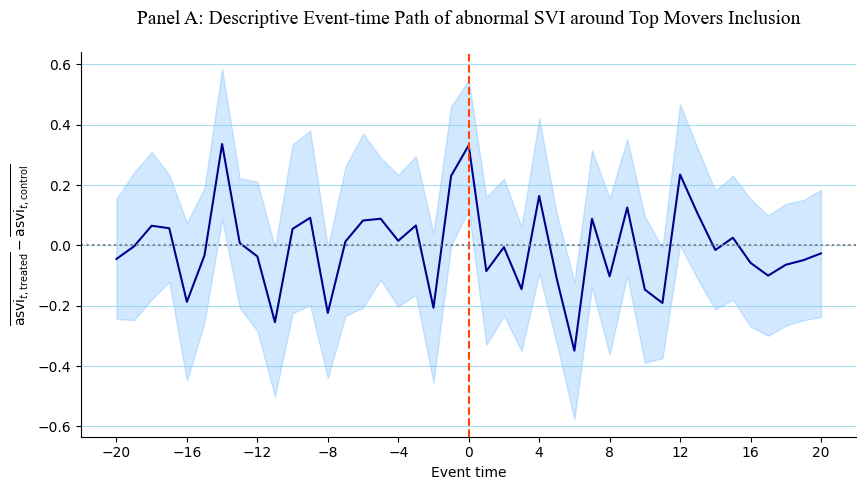

In [109]:
def summarize_event_path(panel, outcome="diff_asvi"):
    s = (
        panel.groupby("rel_time")[outcome]
             .agg(["mean", "std", "count"])
             .reset_index()
    )
    s["se"] = s["std"] / np.sqrt(s["count"])
    s["ci_low"] = s["mean"] - 1.645 * s["se"]
    s["ci_high"] = s["mean"] + 1.645 * s["se"]
    return s

desc_20 = summarize_event_path(pair_panel_20_balanced, outcome="diff_asvi")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(desc_20["rel_time"], desc_20["mean"], color="darkblue")
ax.fill_between(desc_20["rel_time"], desc_20["ci_low"], desc_20["ci_high"], color="dodgerblue", alpha=0.2)

# aesthetic
ax.axvline(0, linestyle="--", color = "orangered")
ax.axhline(0, linestyle=":", color = "grey")
ax.set_xlabel("Event time")
ax.set_ylabel(r"$\overline{\text{asvi}_{t, \text{treated}}} - \overline{\text{asvi}_{t, \text{control}}}$")
ax.set_xticks(range(-20, 21, 4))
ax.set_title(r"Panel A: Descriptive Event-time Path of abnormal SVI around Top Movers Inclusion",
             pad=20, fontsize=14, family="Times New Roman")
ax.grid(True, linestyle="-", alpha=0.7, axis="y", color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("../../../figures/PanelA_event_study_path.pdf", bbox_inches="tight")
plt.show()

This plot is the descriptive output of my matched event-study design. The idea was to isolate whether a stock’s plausible inclusion in Robinhood’s Top Movers list is associated with an unusual increase in investor attention, proxied by abnormal Google search intensity.

The logic starts with the event. A stock is treated on day $t$ if it plausibly enters the Top Movers list, meaning it satisfies the Robinhood-style eligibility rule and is among the day’s largest absolute overnight movers. In my tighter design, treatment could be further restricted to stocks with market cap just above the Robinhood eligibility cutoff, for example $(300,350]$ million USD, because those are the stocks most useful for a near-threshold comparison.

But treatment alone is not enough, because these stocks are also unusual for other reasons. A stock that lands in Top Movers often has a large return shock, a news shock, or both. So I build a matched control group on the same day using stocks just below the eligibility cutoff, typically in $[250,300)$ million USD, that have very similar absolute overnight returns. The purpose of the control is to ask: "if two stocks had similarly extreme overnight moves on the same day, but only one was likely eligible to appear in Robinhood’s Top Movers screen, did the eligible one attract more search attention afterward?" That is the core identification logic.

The outcome is not raw SVI, but abnormal SVI. For each stock-date, I compute:

$$
asvi_{i,t} = \log(1+svi_{i,t}) - \text{median}\big(\log(1+svi_{i,s})\big),
$$

where the median is taken over a pre-event estimation window, such as $[t-21,t-11]$. This transforms search intensity into a deviation from the stock’s own recent normal level. That matters because different stocks have very different baseline popularity. Tesla and a small-cap biotech can never be compared meaningfully in raw SVI levels, but they can be compared in abnormal attention relative to their own history.

Once I have treated and control stocks, I align them in event time. Event time 0 is the day of plausible Top Movers inclusion. Event time -1 is the day before, +1 the day after, and so on. For each event time $k$, I compute:

$$
\text{treated asvi}_{e,k} - \text{control asvi}_{e,k}
$$

for every matched pair $e$. Then I average those differences across all events. So the plotted line is the average treated-minus-control abnormal attention difference at each event time. The shaded band is the uncertainty around that average, typically a 90% confidence interval. That means the plot is not showing raw attention for treated stocks alone. It is showing incremental attention relative to matched controls. This is important. A positive value at event time 0 means: stocks plausibly included in Top Movers attracted more abnormal search attention than similar same-day stocks that had similar overnight return shocks but were just below the market-cap eligibility threshold.

#### Estimate the main inferential event-study on treated-minus-control differences

$$
\Delta asvi_{e,k} = \delta_t + \sum_{k\neq -1}\beta_k 1\{rel\_time = k\} + u_{e,k},
$$

Where $e$ indexes a matched treated, control pair; that is, an event. $k$ indexes event-time such that $k = -5, -4, \ldots, 0, \ldots +5$. Furthermore $\Delta asvi_{e,k}$ is the treated minus control abnormal SVI attention for pair $e$ at time $k$. The treated stock is a plausible Top Movers stock. The control stock is chosen on the same day, close in market cap, and similar in absolute overnight return. The reason for this matching is to net out the generic attention shock associated with extreme returns or contemporaneous news.

For each event time k, I create an indicator $1\{rel\_time=k\}$, which equals 1 when the observation is at event time $k$, and 0 otherwise. So if my inferential window is $[-5,+5]$, I have dummy variables for $k=-5,-4,-3,-2,0,1,2,3,4,5$. I leave one event-time dummy out. That omitted category becomes the reference period. Every included coefficient is then interpreted relative to that omitted event time. It is important to notice therefore that time $k = -1$ is our baseline period! Finally, the most important coefficient is:

$$
\beta_0
=
\Big(E[asvi^{treated}_{e,0} - asvi^{control}_{e,0}]\Big)
-
\Big(E[asvi^{treated}_{e,-1} - asvi^{control}_{e,-1}]\Big),
$$

and our assumption is that $\beta_0 > 0$.

In [102]:
import statsmodels.formula.api as smf

# Start from balanced pair panel
panel_reg = pair_panel_5_balanced.copy()

# Make sure date is datetime
panel_reg["date"] = pd.to_datetime(panel_reg["date"])

# Make rel_time categorical with -1 omitted later in the formula
panel_reg["rel_time_cat"] = panel_reg["rel_time"].astype(int).astype("category")

# Keep only rows needed by the regression and drop missings explicitly
reg_vars = ["diff_asvi", "rel_time_cat", "date", "event_id"]
panel_reg['diff_asvi'] = panel_reg['diff_asvi'].replace([np.inf, -np.inf], np.nan)
panel_reg = panel_reg[reg_vars].dropna().copy()

# Optional sanity checks
print(panel_reg.shape)
print(panel_reg.isna().sum())

# Fit model on the cleaned sample
model = smf.ols(
    formula="diff_asvi ~ C(rel_time_cat, Treatment(reference=-1)) + C(date)",
    data=panel_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_reg["event_id"].to_numpy()}
)

print(model.summary())

(35611, 4)
diff_asvi       0
rel_time_cat    0
date            0
event_id        0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:              diff_asvi   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     6.796
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          4.13e-270
Time:                        20:24:17   Log-Likelihood:                -49410.
No. Observations:               35611   AIC:                         9.988e+04
Df Residuals:                   35083   BIC:                         1.044e+05
Df Model:                         527                                         
Covariance Type:              cluster                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]

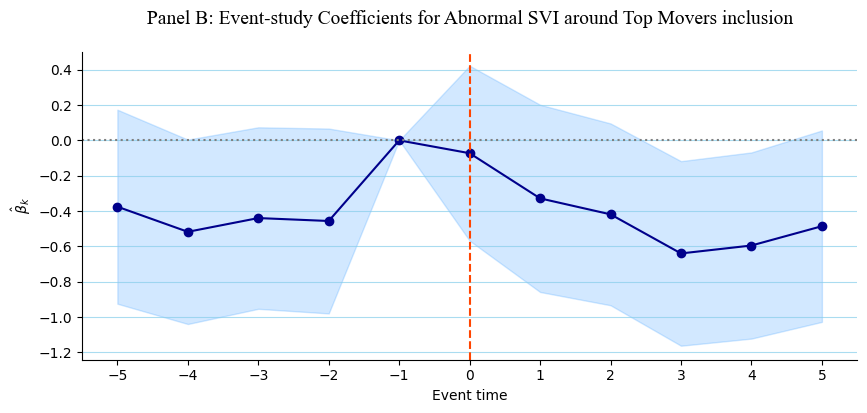

In [68]:
def extract_event_study_coefs(model, rel_times, prefix="C(rel_time_cat, Treatment(reference=-1))"):
    rows = []
    for k in rel_times:
        if k == -1:
            rows.append({"rel_time": k, "coef": 0.0, "se": 0.0})
            continue
        
        name = f"{prefix}[T.{k}]"
        if name in model.params.index:
            coef = model.params[name]
            se = model.bse[name]
        else:
            coef = np.nan
            se = np.nan
        
        rows.append({"rel_time": k, "coef": coef, "se": se})
    
    out = pd.DataFrame(rows)
    out["ci_low"] = out["coef"] - 1.645 * out["se"]
    out["ci_high"] = out["coef"] + 1.645 * out["se"]
    return out

coef_df = extract_event_study_coefs(model, rel_times=list(range(-5, 6)))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(coef_df["rel_time"], coef_df["coef"], marker="o", color="darkblue")
ax.fill_between(coef_df["rel_time"], coef_df["ci_low"], coef_df["ci_high"], alpha=0.2, color="dodgerblue")
ax.axvline(0, linestyle="--", color="orangered")
ax.axhline(0, linestyle=":", color="grey")
ax.set_xlabel("Event time")
ax.set_xticks(range(-5, 6))
ax.set_ylabel(r"$\hat{\beta}_k$")
ax.set_title("Panel B: Event-study Coefficients for Abnormal SVI around Top Movers inclusion",
             pad=20, fontsize=14, family="Times New Roman")
ax.grid(True, linestyle="-", alpha=0.7, axis="y", color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("../../../figures/PanelB_event_study_coefficients.pdf", bbox_inches="tight")
plt.show()

#### Estimate the positive and negative subsamples separately

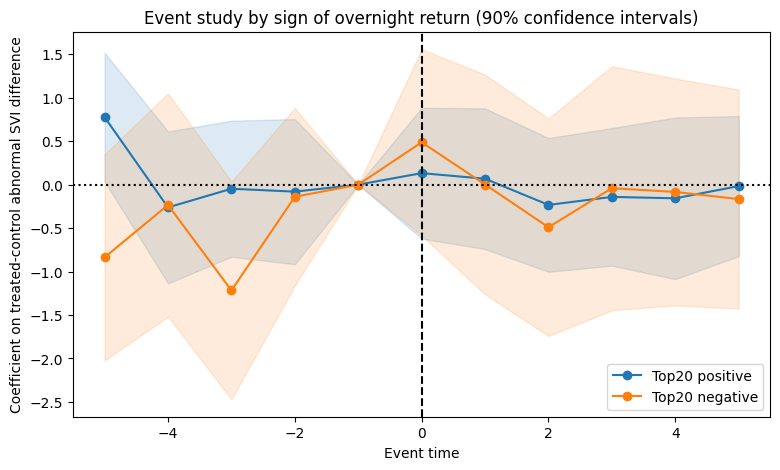

In [146]:
# ------------------------------------------------------------
# 1. BUILD SEPARATE MATCH FILES
# ------------------------------------------------------------
matches_pos = build_event_matches(
    df1,
    event_col="event_main_pos_usable"
)

matches_neg = build_event_matches(
    df1,
    event_col="event_main_neg_usable"
)

# ------------------------------------------------------------
# 2. BUILD PAIR PANELS
# ------------------------------------------------------------
panel_pos_5 = build_pair_panel_fast(df1, matches_pos, event_window=5)
panel_neg_5 = build_pair_panel_fast(df1, matches_neg, event_window=5)

# ------------------------------------------------------------
# 3. KEEP ONLY BALANCED EVENT WINDOWS
# ------------------------------------------------------------
good_pos = panel_pos_5.groupby("event_id")["rel_time"].nunique()
good_pos = good_pos.loc[good_pos == 11].index
panel_pos_5 = panel_pos_5.loc[panel_pos_5["event_id"].isin(good_pos)].copy()

good_neg = panel_neg_5.groupby("event_id")["rel_time"].nunique()
good_neg = good_neg.loc[good_neg == 11].index
panel_neg_5 = panel_neg_5.loc[panel_neg_5["event_id"].isin(good_neg)].copy()

# ------------------------------------------------------------
# 4. RUN REGRESSIONS
# ------------------------------------------------------------
def run_diff_event_reg(panel):
    panel = panel.copy()

    # Keep only the variables used in the regression and drop missings first
    # so that the clustering groups vector has exactly the same length as the
    # estimation sample used by statsmodels.
    panel = panel[["diff_asvi", "rel_time", "date", "event_id"]].dropna().copy()
    panel = panel.reset_index(drop=True)

    # Clean types
    panel["date"] = pd.to_datetime(panel["date"])
    panel["rel_time_cat"] = panel["rel_time"].astype(int).astype("category")

    # Build model first
    model_base = smf.ols(
        formula="diff_asvi ~ C(rel_time_cat, Treatment(reference=-1)) + C(date)",
        data=panel
    )

    # Align cluster groups to exact estimation sample retained by patsy/statsmodels
    used_rows = model_base.data.row_labels
    groups_used = panel.loc[used_rows, "event_id"].to_numpy()

    mod = model_base.fit(
        cov_type="cluster",
        cov_kwds={"groups": groups_used}
    )
    return mod

mod_pos = run_diff_event_reg(panel_pos_5)
mod_neg = run_diff_event_reg(panel_neg_5)

# ------------------------------------------------------------
# 5. EXTRACT EVENT-STUDY COEFFICIENTS WITH CHOSEN CI LEVEL
# ------------------------------------------------------------
def extract_event_study_coefs(
    model,
    rel_times,
    prefix="C(rel_time_cat, Treatment(reference=-1))",
    ci_level=0.90
):
    z_map = {
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576
    }
    if ci_level not in z_map:
        raise ValueError("ci_level must be one of {0.90, 0.95, 0.99}")

    z = z_map[ci_level]

    rows = []
    for k in rel_times:
        if k == -1:
            rows.append({"rel_time": k, "coef": 0.0, "se": 0.0})
            continue

        name = f"{prefix}[T.{k}]"
        if name in model.params.index:
            coef = model.params[name]
            se = model.bse[name]
        else:
            coef = np.nan
            se = np.nan

        rows.append({
            "rel_time": k,
            "coef": coef,
            "se": se
        })

    out = pd.DataFrame(rows)
    out["ci_low"] = out["coef"] - z * out["se"]
    out["ci_high"] = out["coef"] + z * out["se"]
    return out

coef_pos = extract_event_study_coefs(
    mod_pos,
    rel_times=list(range(-5, 6)),
    ci_level=0.90
)

coef_neg = extract_event_study_coefs(
    mod_neg,
    rel_times=list(range(-5, 6)),
    ci_level=0.90
)

# ------------------------------------------------------------
# 6. PLOT WITH 90% CONFIDENCE INTERVALS
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

# Positive group
plt.plot(
    coef_pos["rel_time"],
    coef_pos["coef"],
    marker="o",
    color="tab:blue",
    label="Top20 positive"
)
plt.fill_between(
    coef_pos["rel_time"],
    coef_pos["ci_low"],
    coef_pos["ci_high"],
    color="tab:blue",
    alpha=0.15
)

# Negative group
plt.plot(
    coef_neg["rel_time"],
    coef_neg["coef"],
    marker="o",
    color="tab:orange",
    label="Top20 negative"
)
plt.fill_between(
    coef_neg["rel_time"],
    coef_neg["ci_low"],
    coef_neg["ci_high"],
    color="tab:orange",
    alpha=0.15
)

plt.axvline(0, linestyle="--", color="black")
plt.axhline(0, linestyle=":", color="black")
plt.xlabel("Event time")
plt.ylabel("Coefficient on treated-control abnormal SVI difference")
plt.title("Event study by sign of overnight return (90% confidence intervals)")
plt.legend()
plt.show()

### 2.4. Discussion 

The main conclusion is the following: plausible inclusion in Robinhood’s Top Movers list is associated with a sharp, same-day increase in abnormal Google search attention relative to matched controls, but that effect is short-lived and does not survive into the next trading day. The dynamic pattern is consistent with a contemporaneous salience shock rather than a persistent attention cycle. The coefficients also tell that it seems that at time $t = -1$, we already have an increase in $\textit{asvi}_{i, t}$ which means that some news is probably already filtering in the search behavior of retail investors.

## 3. RD Test

In [2]:
# baseline trading sample
df3 = pd.read_csv('../../../data/processed/attention_sample.csv')

# parse dates
df3['date'] = pd.to_datetime(df3['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_21931/1184975288.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('../../../data/processed/attention_sample.csv')


In [3]:
df3 = df3.sort_values(['ticker', 'date']).copy()

# market cap at market open in millions
df3['shrout_lag1'] = df3.groupby('ticker')['shrout'].shift(1)
df3['mktcap'] = (df3['open_price'] * df3['shrout_lag1']) / 1e3

# overnight return from previous close to today's open
df3["close_price_lag"] = df3.groupby("ticker")["close_price"].shift(1)
df3["overnight_ret"] = (df3["open_price"] / df3["close_price_lag"]) - 1

# absolute overnight return
df3["abs_overnight_ret"] = df3["overnight_ret"].abs()

# absolute return
df3["abs_ret"] = df3['ret'].abs()

# absolute intra ret
df3['intra_ret'] = (df3['close_price'] / df3['open_price']) - 1
df3['abs_intra_ret'] = df3['intra_ret'].abs()

# ! SMALL GLITCH
df3['overnight_ret'] = df3['intra_ret']
df3['abs_overnight_ret'] = df3['abs_intra_ret']

I build an abnormal measure for Google Search Volume Index.

In [4]:
# build asvi_t as ln(1 + svi_t / mean(svi_t) for t in [t-1, t-21])
def compute_asvi(group, value_col="svi"):
    s = group[value_col]
    baseline = s.shift(1).rolling(window=21).mean()
    out = group.copy()
    out["asvi_t"] = np.log1p(s / (baseline + 1))
    return out

df3 = df3.groupby("ticker", group_keys=False).apply(compute_asvi).reset_index(drop=True)

# look at the percentage of nan values in asvi_t
nan_percentage = df3["asvi_t"].isna().mean() * 100
print(f"Percentage of NaN values in asvi_t: {nan_percentage:.2f}%")

# look at the percentage of infinite (positive or negative) values in asvi_t
inf_percentage = np.isinf(df3["asvi_t"]).mean() * 100
print(f"Percentage of infinite values in asvi_t: {inf_percentage:.2f}%")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_21931/3399074424.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df3 = df3.groupby("ticker", group_keys=False).apply(compute_asvi).reset_index(drop=True)


Percentage of NaN values in asvi_t: 10.26%
Percentage of infinite values in asvi_t: 0.00%


In [6]:
df3.columns

Index(['date', 'users_close', 'users_start', 'users_last', 'intraday_userchg',
       'ticker', 'permno', 'ret', 'prc', 'vol', 'shrout', 'exchcd', 'symro',
       'symsu', 'buy_num_trades_LR', 'sell_num_trades_LR', 'total_trade_LR',
       'buy_vol_LR', 'sell_vol_LR', 'close_price', 'open_price', 'close_vol',
       'open_vol', 'total_vol_m', 'total_n_trades_m', 'intra_ret',
       'buy_num_trades_tick', 'sell_num_trades_tick', 'buy_vol_tick',
       'sell_vol_tick', 'total_trade_tick', 'buy_num_trades_wrds',
       'sell_num_trades_wrds', 'buy_vol_wrds', 'sell_vol_wrds',
       'total_trade_wrds', 'bs_ratio_num', 'bs_ratio_vol',
       'buy_num_trades_retail', 'sell_num_trades_retail', 'buy_vol_retail',
       'sell_vol_retail', 'total_trade_retail', 'total_vol_retail',
       'bs_ratio_retail_vol', 'bs_ratio_retail_num', 'intra_volatility',
       'buy_num_trades_inst50k', 'sell_num_trades_inst50k', 'buy_vol_inst50k',
       'sell_vol_inst50k', 'total_trade_inst50k', 'total_vol_inst5

In [9]:
# ============================================================
# REQUIRED COLUMNS IN df
# ------------------------------------------------------------
# date              : trading day
# ticker            : stock identifier
# mktcap            : market capitalization in million USD
# overnight_ret     : overnight return (signed)
# asvi              : intraday change in Robinhood users
# ============================================================


def build_topmover_rd_sample(
    df,
    upper_treat_cap=350,
    lower_control_cap=250,
    cutoff=300,
    top_n=20,
    ratio_low=0.5,
    ratio_high=2.0,
    keep_all_eligible_controls=True
):
    """
    Build an RD sample inspired by Barber et al. (2022):
    - Treated-side candidates:
        market cap in (300, upper_treat_cap]
        AND top_n by abs overnight return among stocks with mktcap > 300
    - Control-side candidates:
        market cap in [lower_control_cap, 300]
        AND abs overnight return sufficiently close to at least one treated-side candidate
          using the ratio restriction:
              abs_ret_treated / abs_ret_control in [ratio_low, ratio_high]

    Important:
    This function uses the return-based matching logic only as a SAMPLE RESTRICTION.
    The regression itself will still estimate the discontinuity at the 300 cutoff.

    Parameters
    ----------
    df : pd.DataFrame
    upper_treat_cap : float
        Upper cap bound for treated-side sample.
    lower_control_cap : float
        Lower cap bound for below-cutoff controls.
    cutoff : float
        RD threshold, usually 300.
    top_n : int
        Number of top absolute-return movers above the cutoff to keep.
    ratio_low, ratio_high : float
        Allowed range for abs_ret_treated / abs_ret_control.
    keep_all_eligible_controls : bool
        If True, keep every below-cutoff stock that matches at least one treated stock.
        If False, keep only the single closest treated-return distance match for each control.

    Returns
    -------
    rd_df : pd.DataFrame
        Restricted RD sample.
    """

    data = df.copy()
    data = data.dropna(subset=["date", "ticker", "mktcap", "overnight_ret", "asvi_t"]).copy()
    data["date"] = pd.to_datetime(data["date"])
    data["abs_overnight_ret"] = data["overnight_ret"].abs()

    out = []

    for d, g in data.groupby("date"):
        g = g.copy()

        # --------------------------------------------------------
        # 1. Above-threshold ranking among stocks with mktcap > cutoff
        # --------------------------------------------------------
        eligible_above = g[g["mktcap"] > cutoff].copy()
        if eligible_above.empty:
            continue

        eligible_above = eligible_above.sort_values("abs_overnight_ret", ascending=False)
        eligible_above["rank_above_cutoff"] = np.arange(1, len(eligible_above) + 1)

        treated = eligible_above[
            (eligible_above["mktcap"] > cutoff) &
            (eligible_above["mktcap"] <= upper_treat_cap) &
            (eligible_above["rank_above_cutoff"] <= top_n)
        ].copy()

        if treated.empty:
            continue

        treated["sample_side"] = "above"
        treated["rd_treated"] = 1

        # --------------------------------------------------------
        # 2. Below-threshold comparable controls
        # --------------------------------------------------------
        controls_pool = g[
            (g["mktcap"] >= lower_control_cap) &
            (g["mktcap"] < cutoff)
        ].copy()

        if controls_pool.empty:
            continue

        matched_controls_idx = set()
        control_best_distance = {}

        treated_abs = treated["abs_overnight_ret"].to_numpy()

        for idx, row in controls_pool.iterrows():
            c_abs = row["abs_overnight_ret"]

            # Zero-handling
            if c_abs == 0:
                valid = np.where(treated_abs == 0)[0]
                if len(valid) == 0:
                    continue
                min_dist = 0.0
            else:
                ratios = treated_abs / c_abs
                valid = np.where((ratios >= ratio_low) & (ratios <= ratio_high))[0]
                if len(valid) == 0:
                    continue
                min_dist = np.min(np.abs(treated_abs[valid] - c_abs))

            matched_controls_idx.add(idx)
            control_best_distance[idx] = min_dist

        if not matched_controls_idx:
            continue

        controls = controls_pool.loc[list(matched_controls_idx)].copy()
        controls["best_treated_absret_distance"] = controls.index.map(control_best_distance)
        controls["sample_side"] = "below"
        controls["rd_treated"] = 0

        if not keep_all_eligible_controls:
            # Optional tighter restriction:
            # for each day, keep only the most comparable below-threshold stocks
            controls = controls.sort_values("best_treated_absret_distance").copy()

        # --------------------------------------------------------
        # 3. Stack into daily RD sample
        # --------------------------------------------------------
        day_sample = pd.concat([treated, controls], axis=0, ignore_index=True)
        out.append(day_sample)

    if not out:
        return pd.DataFrame()

    rd_df = pd.concat(out, axis=0, ignore_index=True)

    # Running variable centered at cutoff
    rd_df["running"] = rd_df["mktcap"] - cutoff

    return rd_df


def run_rd_on_restricted_sample(
    rd_df,
    outcome="asvi_t",
    cutoff=300,
    degree=1,
    cluster="date"
):
    """
    Estimate:
        outcome_it = beta0
                   + beta1 * 1(mktcap >= cutoff)
                   + polynomial in (mktcap - cutoff)
                   + interactions with 1(mktcap >= cutoff)
                   + error_it

    on the restricted RD sample produced above.

    Parameters
    ----------
    rd_df : pd.DataFrame
    outcome : str
        Dependent variable.
    cutoff : float
        RD cutoff.
    degree : int
        Polynomial degree for the running variable.
    cluster : str or None
        If 'date', cluster SE by date.
        If None, use HC1 robust SE.

    Returns
    -------
    results : statsmodels result
    """

    if rd_df.empty:
        raise ValueError("rd_df is empty. No restricted RD sample was created.")

    df_reg = rd_df.copy()
    df_reg["D"] = (df_reg["mktcap"] > cutoff).astype(int)

    # Polynomial terms
    for n in range(1, degree + 1):
        df_reg[f"run{n}"] = df_reg["running"] ** n

    rhs = ["D"]
    for n in range(1, degree + 1):
        rhs.append(f"run{n}")
        rhs.append(f"D:run{n}")

    formula = f"{outcome} ~ " + " + ".join(rhs)
    model = smf.ols(formula, data=df_reg)

    if cluster == "date":
        results = model.fit(
            cov_type="cluster",
            cov_kwds={"groups": df_reg["date"]}
        )
    else:
        results = model.fit(cov_type="HC1")

    return results


def rd_diagnostics(rd_df):
    """
    Basic diagnostics for the restricted sample.
    """
    if rd_df.empty:
        print("RD sample is empty.")
        return

    print("Total observations:", len(rd_df))
    print("Above-cutoff observations:", (rd_df["mktcap"] > 300).sum())
    print("Below-cutoff observations:", (rd_df["mktcap"] <= 300).sum())
    print("Unique dates:", rd_df["date"].nunique())
    print("Unique tickers:", rd_df["ticker"].nunique())

    print("\nMarket cap summary by side:")
    print(rd_df.groupby("sample_side")["mktcap"].describe())

    print("\nAbsolute overnight return summary by side:")
    print(rd_df.groupby("sample_side")["abs_overnight_ret"].describe())


# ============================================================
# EXAMPLE USAGE
# ============================================================

# 1. Build restricted RD sample
rd_df = build_topmover_rd_sample(
    df3,
    upper_treat_cap=350,
    lower_control_cap=250,
    cutoff=300,
    top_n=20,
    ratio_low=0.5,
    ratio_high=2.0,
    keep_all_eligible_controls=True
)

# 2. Diagnostics
# rd_diagnostics(rd_df)

# 3. Estimate RD with different polynomial orders
res_lin = run_rd_on_restricted_sample(rd_df, outcome="asvi_t", degree=1, cluster="date")
res_quad = run_rd_on_restricted_sample(rd_df, outcome="asvi_t", degree=2, cluster="date")
res_cubic = run_rd_on_restricted_sample(rd_df, outcome="asvi_t", degree=3, cluster="date")

print("\n================ LINEAR RD ================\n")
print(res_lin.summary())

print("\n================ QUADRATIC RD ================\n")
print(res_quad.summary())

print("\n================ CUBIC RD ================\n")
print(res_cubic.summary())


================ LINEAR RD ================

                            OLS Regression Results                            
Dep. Variable:                 asvi_t   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.132
Date:                Tue, 07 Apr 2026   Prob (F-statistic):            0.00672
Time:                        16:17:28   Log-Likelihood:                -3299.3
No. Observations:                3066   AIC:                             6607.
Df Residuals:                    3062   BIC:                             6631.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

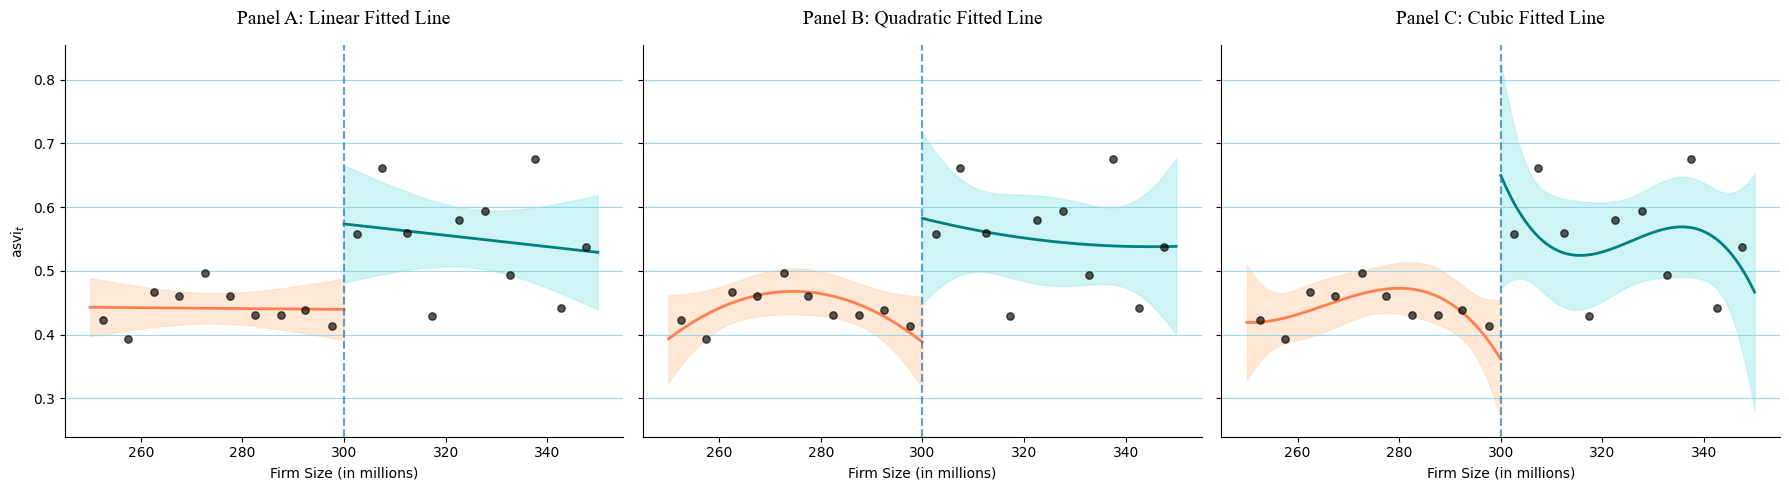

In [10]:
def _make_binned_scatter(
    df,
    x_col="mktcap",
    y_col="asvi_t",
    cutoff=300,
    n_bins_each_side=10
):
    """
    Create binned scatterplot data separately below and above the cutoff.
    Returns one dataframe with bin-level mean x and mean y.
    """
    d = df[[x_col, y_col]].dropna().copy()

    below = d[d[x_col] <= cutoff].copy()
    above = d[d[x_col] > cutoff].copy()

    binned_parts = []

    # Below-cutoff bins
    if len(below) > 0:
        below["bin"] = pd.cut(
            below[x_col],
            bins=np.linspace(below[x_col].min(), cutoff, n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )
        b0 = below.groupby("bin", observed=False).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean"),
            n=(y_col, "size")
        ).dropna().reset_index(drop=True)
        binned_parts.append(b0)

    # Above-cutoff bins
    if len(above) > 0:
        above["bin"] = pd.cut(
            above[x_col],
            bins=np.linspace(cutoff, above[x_col].max(), n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )
        b1 = above.groupby("bin", observed=False).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean"),
            n=(y_col, "size")
        ).dropna().reset_index(drop=True)
        binned_parts.append(b1)

    if not binned_parts:
        return pd.DataFrame(columns=["x_mean", "y_mean", "n"])

    return pd.concat(binned_parts, ignore_index=True)


def _fit_side_polynomial(side_df, degree, x_col="mktcap", y_col="asvi_t"):
    """
    Fit polynomial regression separately on one side of the cutoff:
        y = beta0 + beta1*x + beta2*x^2 + ...
    Returns fitted model.
    """
    d = side_df[[x_col, y_col]].dropna().copy()

    X = pd.DataFrame({"const": 1.0}, index=d.index)
    for p in range(1, degree + 1):
        X[f"x{p}"] = d[x_col] ** p

    model = sm.OLS(d[y_col], X).fit()
    return model


def _predict_side(model, x_grid, degree):
    """
    Get fitted values and 90% CI on a grid for one side.
    """
    Xg = pd.DataFrame({"const": np.ones(len(x_grid))})
    for p in range(1, degree + 1):
        Xg[f"x{p}"] = x_grid ** p

    pred = model.get_prediction(Xg).summary_frame(alpha=0.10)  # 90% CI
    out = pd.DataFrame({
        "x": x_grid,
        "yhat": pred["mean"].to_numpy(),
        "ci_low": pred["mean_ci_lower"].to_numpy(),
        "ci_high": pred["mean_ci_upper"].to_numpy()
    })
    return out


def plot_barber_figure5_style(
    rd_df,
    x_col="mktcap",
    y_col="asvi_t",
    cutoff=300,
    degrees=(1, 2, 3),
    n_bins_each_side=10,
    figsize=(18, 5),
    point_alpha=0.65,
    line_width=2.0,
    ci_alpha=0.6
):
    """
    Reproduce a Figure 5 style RD plot:
    - binned scatterplot
    - separate fits below/above cutoff
    - 90% confidence bands
    - linear, quadratic, cubic panels on one row
    """

    d = rd_df[[x_col, y_col]].dropna().copy()

    # Binned scatter data
    binned = _make_binned_scatter(
        d,
        x_col=x_col,
        y_col=y_col,
        cutoff=cutoff,
        n_bins_each_side=n_bins_each_side
    )

    below = d[d[x_col] <= cutoff].copy()
    above = d[d[x_col] > cutoff].copy()

    fig, axes = plt.subplots(1, len(degrees), figsize=figsize, sharey=True)

    if len(degrees) == 1:
        axes = [axes]

    panel_titles = {
        1: "Panel A: Linear Fitted Line",
        2: "Panel B: Quadratic Fitted Line",
        3: "Panel C: Cubic Fitted Line"
    }

    for ax, deg in zip(axes, degrees):
        # ----------------------------------------------------
        # 1. Binned scatter
        # ----------------------------------------------------
        ax.scatter(
            binned["x_mean"],
            binned["y_mean"],
            alpha=point_alpha,
            s=28,
            color="black",
            zorder=3
        )

        # ----------------------------------------------------
        # 2. Separate polynomial fits below and above cutoff
        # ----------------------------------------------------
        if len(below) > 0:
            model_below = _fit_side_polynomial(below, degree=deg, x_col=x_col, y_col=y_col)
            xg_below = np.linspace(below[x_col].min(), cutoff, 200)
            pred_below = _predict_side(model_below, xg_below, degree=deg)

            ax.plot(pred_below["x"], pred_below["yhat"], linewidth=line_width, color="coral")
            ax.fill_between(
                pred_below["x"],
                pred_below["ci_low"],
                pred_below["ci_high"],
                alpha=ci_alpha,
                color="peachpuff"
            )

        if len(above) > 0:
            model_above = _fit_side_polynomial(above, degree=deg, x_col=x_col, y_col=y_col)
            xg_above = np.linspace(cutoff, above[x_col].max(), 200)
            pred_above = _predict_side(model_above, xg_above, degree=deg)

            ax.plot(pred_above["x"], pred_above["yhat"], linewidth=line_width, color="teal")
            ax.fill_between(
                pred_above["x"],
                pred_above["ci_low"],
                pred_above["ci_high"],
                alpha=ci_alpha,
                color="paleturquoise"
            )

        # ----------------------------------------------------
        # 3. Cutoff line and formatting
        # ----------------------------------------------------
        ax.axvline(cutoff, linestyle="--", alpha=0.7)
        ax.set_title(panel_titles.get(deg, f"Degree {deg}"), fontsize=14, family="Times New Roman", pad=15)
        ax.set_xlabel("Firm Size (in millions)")
        ax.grid(axis="y", alpha=0.8, color="skyblue")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(r"$\text{asvi}_t$")

    plt.tight_layout()
    plt.savefig("../../../figures/Barber_Figure5_Style_ASVI.pdf", bbox_inches="tight")
    plt.show()


# ============================================================
# RUN THE FIGURE
# ============================================================

plot_barber_figure5_style(
    rd_df,
    x_col="mktcap",
    y_col="asvi_t",
    cutoff=300,
    degrees=(1, 2, 3),
    n_bins_each_side=10,   # 10 bins below + 10 bins above, close to the published figure
    figsize=(18, 5)
)

EXTREMELLY INTERESTING FINDING AND STATISTICALLY SIGNIFICANT!

#### results with 50 bandwith

#### 75 bandwith

#### 100 

#### 125

#### placebo